# Hierarchical Models – Normalized Data (Pause-Mean & Z-Score)

This notebook replicates the hierarchical LMM analyses using **two normalization strategies**:

### Normalization A: Pause-Mean Normalization
Each block value is expressed as a **percentage of the subject's mean pause-block value**:
$$\text{norm}_i = \frac{\text{value}_i}{\text{mean}(\text{pause blocks})} \times 100$$

- Pause blocks scatter around ~100%; stim blocks show deviation from resting level.
- All subjects retained (no BL required).

### Normalization B: Within-Subject Z-Score
$$z_i = \frac{\text{value}_i - \bar{x}_{\text{subject}}}{\text{SD}_{\text{subject}}}$$

- Removes between-subject variance and scale differences entirely.
- Effects in SD units.

### Models (same 3 families, applied to each normalization × each DV)
1. **Block-type effect** – stim vs non-stim / stim vs pause
2. **Time effect** – linear trend, and time × block-type interaction
3. **Immediate effect** – percent change from previous block

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings

warnings.filterwarnings('ignore')
sns.set(style='white', context='talk')

print('Setup done.')

Setup done.


## 1. Load & reshape data

In [2]:
RATE_PATH = r'final_firing_rates_wide.csv'
AMP_PATH  = r'final_amplitudes_wide.csv'


def load_and_melt(path, value_name):
    df = pd.read_csv(path)
    block_cols = [c for c in df.columns if c != 'Subject_ID']

    long = df.melt(id_vars='Subject_ID',
                   value_vars=block_cols,
                   var_name='block_label',
                   value_name=value_name)
    long = long.dropna(subset=[value_name]).copy()

    long['block_number'] = long['block_label'].apply(
        lambda x: 0 if x == 'BL' else int(x.split('_')[1])
    )

    def _type(label):
        if label == 'BL':
            return 'baseline'
        num = int(label.split('_')[1])
        return 'stim' if num % 2 == 1 else 'pause'

    long['block_type'] = long['block_label'].apply(_type)
    long['Subject_ID'] = long['Subject_ID'].astype(str)
    long = long.sort_values(['Subject_ID', 'block_number']).reset_index(drop=True)
    return long


df_rate = load_and_melt(RATE_PATH, 'firing_rate')
df_amp  = load_and_melt(AMP_PATH,  'amplitude')

print(f'Firing-rate long shape : {df_rate.shape}')
print(f'Amplitude   long shape : {df_amp.shape}')
display(df_rate.head(10))

Firing-rate long shape : (172, 5)
Amplitude   long shape : (171, 5)


,Subject_ID,block_label,firing_rate,block_number,block_type
0,485,BL,12.610973,0,baseline
1,485,Block_1,5.796996,1,stim
2,485,Block_2,7.005146,2,pause
3,485,Block_3,2.921098,3,stim
4,485,Block_4,2.064271,4,pause
5,485,Block_5,3.434616,5,stim
6,485,Block_6,7.596021,6,pause
7,485,Block_7,4.700520,7,stim
8,485,Block_8,3.400000,8,pause
9,486,BL,6.167572,0,baseline


---
## 2. Normalize the data

### A – Pause-mean normalization
### B – Within-subject z-score

In [3]:
def normalize_pause_mean(df, dv):
    """
    Express each block as % of the subject's mean pause-block value.
    Returns a new column name: '{dv}_pause_pct'
    """
    col = f'{dv}_pause_pct'
    pause_means = (df[df['block_type'] == 'pause']
                   .groupby('Subject_ID')[dv].mean())
    df = df.copy()
    df['_pause_mean'] = df['Subject_ID'].map(pause_means)
    df[col] = (df[dv] / df['_pause_mean']) * 100
    df = df.drop(columns='_pause_mean')
    return df, col


def normalize_zscore(df, dv):
    """
    Z-score each value within subject.
    Returns a new column name: '{dv}_z'
    """
    col = f'{dv}_z'
    stats = df.groupby('Subject_ID')[dv].agg(['mean', 'std'])
    df = df.copy()
    df['_mean'] = df['Subject_ID'].map(stats['mean'])
    df['_std']  = df['Subject_ID'].map(stats['std'])
    df[col] = (df[dv] - df['_mean']) / df['_std']
    df = df.drop(columns=['_mean', '_std'])
    # drop if std was 0 (single-observation subjects)
    df = df[np.isfinite(df[col])].copy()
    return df, col


# Apply normalizations
df_rate, rate_pause_col = normalize_pause_mean(df_rate, 'firing_rate')
df_rate, rate_z_col     = normalize_zscore(df_rate, 'firing_rate')

df_amp, amp_pause_col = normalize_pause_mean(df_amp, 'amplitude')
df_amp, amp_z_col     = normalize_zscore(df_amp, 'amplitude')

print('Normalized columns added:')
print(f'  Rate: {rate_pause_col}, {rate_z_col}')
print(f'  Amp:  {amp_pause_col}, {amp_z_col}')
print()

# Quick check – pause-mean normalization: pause blocks should average ~100
for label, df, col in [('Rate', df_rate, rate_pause_col),
                        ('Amp',  df_amp,  amp_pause_col)]:
    pause_mean = df[df['block_type'] == 'pause'][col].mean()
    stim_mean  = df[df['block_type'] == 'stim'][col].mean()
    print(f'{label} pause-pct: pause mean = {pause_mean:.1f}%, stim mean = {stim_mean:.1f}%')

Normalized columns added:
  Rate: firing_rate_pause_pct, firing_rate_z
  Amp:  amplitude_pause_pct, amplitude_z

Rate pause-pct: pause mean = 100.0%, stim mean = 97.9%
Amp pause-pct: pause mean = 100.0%, stim mean = 93.6%


---
## 3. Helpers

In [4]:
def fit_lmm(formula, data, groups_col='Subject_ID', reml=True):
    model = smf.mixedlm(formula, data=data, groups=data[groups_col])
    result = model.fit(reml=reml)
    return result


def print_model(result, title=''):
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(result.summary())
    print()


def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

---
## 4. Model 1 – Effect of Block Type

### 1A: Stim vs Non-Stim (BL + pause)
### 1B: Stim vs Pause only

In [5]:
def run_block_type_models(df, dv, label):
    results = {}

    # 1A  stim vs non-stim
    df_1a = df.copy()
    df_1a['is_stim'] = (df_1a['block_type'] == 'stim').astype(int)
    res_1a = fit_lmm(f'{dv} ~ is_stim', df_1a)
    print_model(res_1a, f'{label} – Model 1A: Stim vs Non-Stim')
    results['1A'] = res_1a

    # 1B  stim vs pause only
    df_1b = df[df['block_type'].isin(['stim', 'pause'])].copy()
    df_1b['is_stim'] = (df_1b['block_type'] == 'stim').astype(int)
    res_1b = fit_lmm(f'{dv} ~ is_stim', df_1b)
    print_model(res_1b, f'{label} – Model 1B: Stim vs Pause')
    results['1B'] = res_1b

    return results

### Pause-Mean Normalized

In [6]:
rate_m1_pause = run_block_type_models(df_rate, rate_pause_col,
                                      'Firing Rate (pause-pct)')

Firing Rate (pause-pct) – Model 1A: Stim vs Non-Stim
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate_pause_pct
No. Observations: 172     Method:             REML                 
No. Groups:       12      Scale:              2985.7062            
Min. group size:  9       Log-Likelihood:     -925.8075            
Max. group size:  31      Converged:          Yes                  
Mean group size:  14.3                                             
---------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|    [0.025    0.975]
---------------------------------------------------------------------
Intercept     106.922      5.818   18.378   0.000    95.519   118.325
is_stim        -8.997      8.347   -1.078   0.281   -25.358     7.363
Group Var       0.000      1.776                                     

Firing Rate (pause-pct) – Model 1B: Stim vs Pause
               

In [7]:
amp_m1_pause = run_block_type_models(df_amp, amp_pause_col,
                                     'Amplitude (pause-pct)')

Amplitude (pause-pct) – Model 1A: Stim vs Non-Stim
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude_pause_pct
No. Observations: 171     Method:             REML               
No. Groups:       12      Scale:              616.6600           
Min. group size:  9       Log-Likelihood:     -790.3822          
Max. group size:  31      Converged:          Yes                
Mean group size:  14.2                                           
-------------------------------------------------------------------
             Coef.    Std.Err.     z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------
Intercept   102.823      3.200   32.133   0.000    96.551   109.094
is_stim      -9.275      3.805   -2.438   0.015   -16.732    -1.817
Group Var    37.321      1.527                                     

Amplitude (pause-pct) – Model 1B: Stim vs Pause
              Mixed Linear Model Regression 

### Z-Score Normalized

In [8]:
rate_m1_z = run_block_type_models(df_rate, rate_z_col,
                                  'Firing Rate (z-score)')

Firing Rate (z-score) – Model 1A: Stim vs Non-Stim
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate_z
No. Observations: 172     Method:             REML         
No. Groups:       12      Scale:              0.9204       
Min. group size:  9       Log-Likelihood:     -238.6198    
Max. group size:  31      Converged:          Yes          
Mean group size:  14.3                                     
------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     0.135     0.101   1.345  0.179  -0.062   0.332
is_stim      -0.287     0.147  -1.960  0.050  -0.574  -0.000
Group Var     0.000                                         

Firing Rate (z-score) – Model 1B: Stim vs Pause
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate_z
No. Observations

In [9]:
amp_m1_z = run_block_type_models(df_amp, amp_z_col,
                                 'Amplitude (z-score)')

Amplitude (z-score) – Model 1A: Stim vs Non-Stim
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude_z
No. Observations: 171     Method:             REML       
No. Groups:       12      Scale:              0.8935     
Min. group size:  9       Log-Likelihood:     -234.7317  
Max. group size:  31      Converged:          Yes        
Mean group size:  14.2                                   
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.205     0.100   2.059  0.039   0.010   0.400
is_stim    -0.433     0.145  -2.992  0.003  -0.717  -0.149
Group Var   0.000                                         

Amplitude (z-score) – Model 1B: Stim vs Pause
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude_z
No. Observations: 161     Method:             RE

### Visualisations – Block-Type Effect

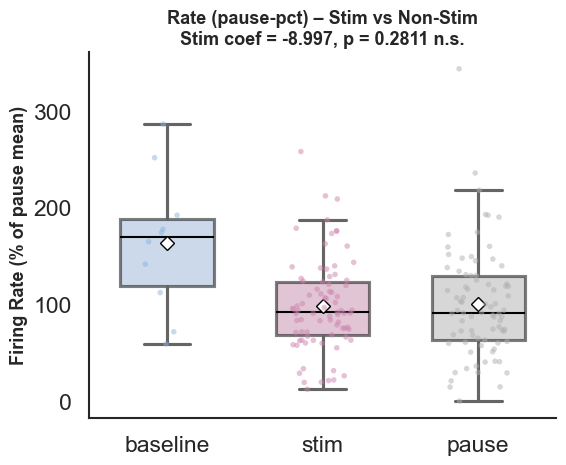

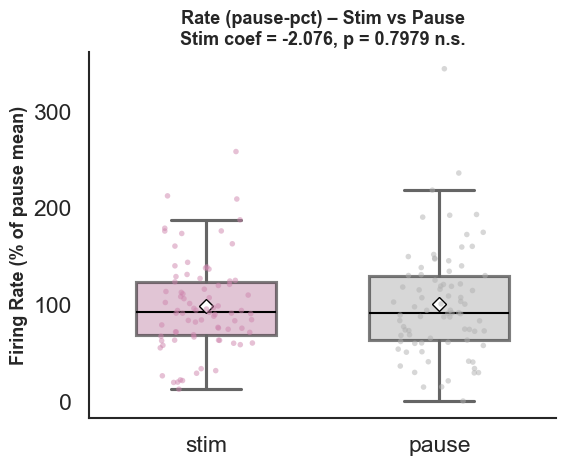

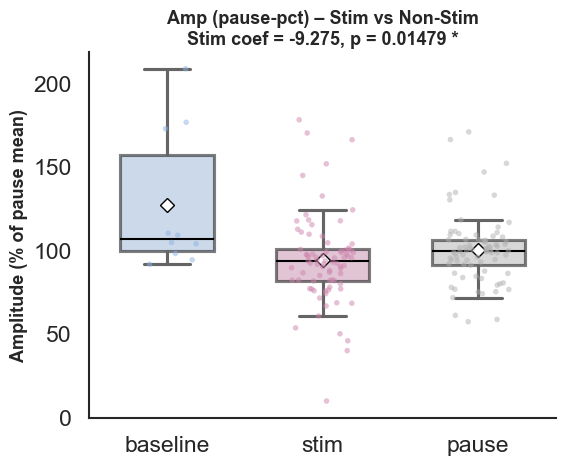

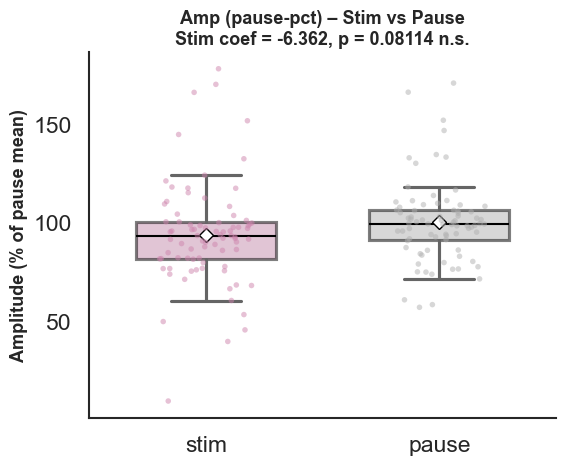

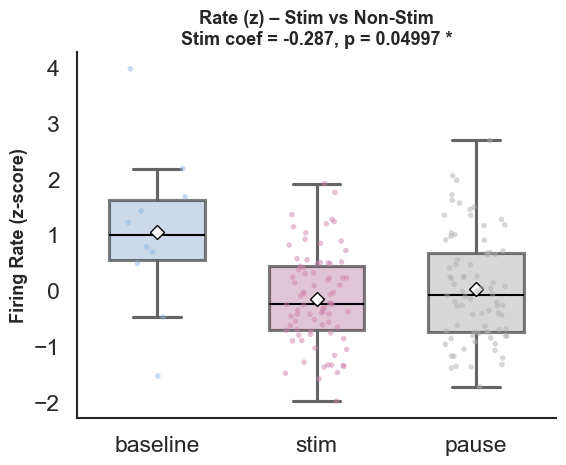

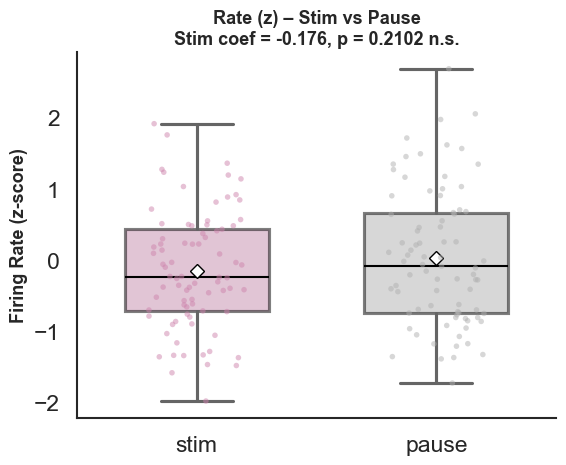

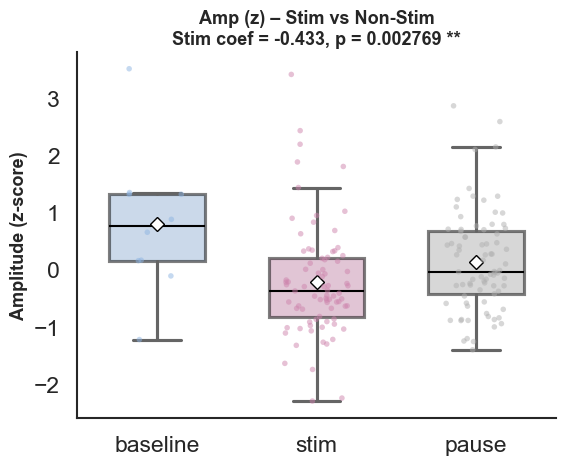

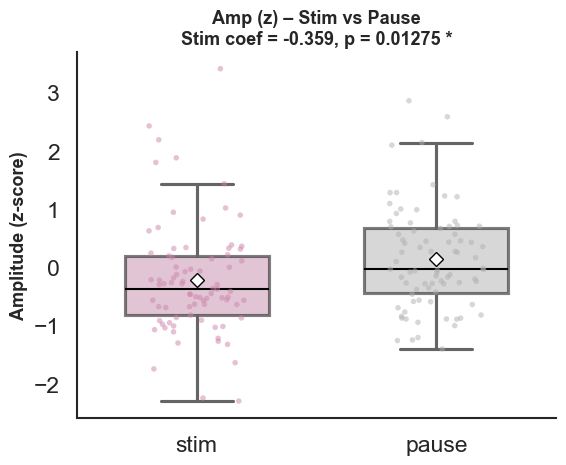

In [10]:
def plot_block_type(df, dv, label, model_result, title='', exclude_baseline=False):
    data = df.copy()
    if exclude_baseline:
        data = data[data['block_type'] != 'baseline']

    fig, ax = plt.subplots(figsize=(6, 5))
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0', 'baseline': '#8db4e2'}
    order = ['baseline', 'stim', 'pause'] if not exclude_baseline else ['stim', 'pause']

    sns.boxplot(data=data, x='block_type', y=dv, order=order,
                palette=palette, width=0.6, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'white',
                           'markeredgecolor': 'black', 'markersize': 7},
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False, zorder=2, ax=ax)
    sns.stripplot(data=data, x='block_type', y=dv, order=order,
                  palette=palette, size=4, alpha=0.5,
                  linewidth=0, zorder=3, ax=ax, jitter=0.2)

    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.3f}, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=13, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


# -- Pause-pct --
plot_block_type(df_rate, rate_pause_col, 'Firing Rate (% of pause mean)',
                rate_m1_pause['1A'], 'Rate (pause-pct) – Stim vs Non-Stim')
plot_block_type(df_rate, rate_pause_col, 'Firing Rate (% of pause mean)',
                rate_m1_pause['1B'], 'Rate (pause-pct) – Stim vs Pause',
                exclude_baseline=True)

plot_block_type(df_amp, amp_pause_col, 'Amplitude (% of pause mean)',
                amp_m1_pause['1A'], 'Amp (pause-pct) – Stim vs Non-Stim')
plot_block_type(df_amp, amp_pause_col, 'Amplitude (% of pause mean)',
                amp_m1_pause['1B'], 'Amp (pause-pct) – Stim vs Pause',
                exclude_baseline=True)

# -- Z-score --
plot_block_type(df_rate, rate_z_col, 'Firing Rate (z-score)',
                rate_m1_z['1A'], 'Rate (z) – Stim vs Non-Stim')
plot_block_type(df_rate, rate_z_col, 'Firing Rate (z-score)',
                rate_m1_z['1B'], 'Rate (z) – Stim vs Pause',
                exclude_baseline=True)

plot_block_type(df_amp, amp_z_col, 'Amplitude (z-score)',
                amp_m1_z['1A'], 'Amp (z) – Stim vs Non-Stim')
plot_block_type(df_amp, amp_z_col, 'Amplitude (z-score)',
                amp_m1_z['1B'], 'Amp (z) – Stim vs Pause',
                exclude_baseline=True)

---
## 5. Model 2 – Effect of Time

### 2A: Overall time trend
### 2B: Time × block-type interaction (stim & pause only)

In [11]:
def run_time_models(df, dv, label):
    results = {}

    # 2A  overall time trend
    res_2a = fit_lmm(f'{dv} ~ block_number', df)
    print_model(res_2a, f'{label} – Model 2A: Time Trend')
    results['2A'] = res_2a

    # 2B  time x block_type
    df_2b = df[df['block_type'].isin(['stim', 'pause'])].copy()
    df_2b['is_stim'] = (df_2b['block_type'] == 'stim').astype(int)
    res_2b = fit_lmm(f'{dv} ~ block_number * is_stim', df_2b)
    print_model(res_2b, f'{label} – Model 2B: Time x Block-Type')
    results['2B'] = res_2b

    return results

### Pause-Mean Normalized

In [12]:
rate_m2_pause = run_time_models(df_rate, rate_pause_col,
                                'Firing Rate (pause-pct)')

Firing Rate (pause-pct) – Model 2A: Time Trend
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate_pause_pct
No. Observations: 172     Method:             REML                 
No. Groups:       12      Scale:              2853.5895            
Min. group size:  9       Log-Likelihood:     -924.6035            
Max. group size:  31      Converged:          Yes                  
Mean group size:  14.3                                             
--------------------------------------------------------------------
                   Coef.   Std.Err.    z     P>|z|   [0.025   0.975]
--------------------------------------------------------------------
Intercept         117.723     6.535  18.014  0.000  104.914  130.531
block_number       -1.804     0.705  -2.559  0.010   -3.185   -0.422
Group Var           1.199     4.657                                 

Firing Rate (pause-pct) – Model 2B: Time x Block-Type
               Mixed Li

In [13]:
amp_m2_pause = run_time_models(df_amp, amp_pause_col,
                               'Amplitude (pause-pct)')

Amplitude (pause-pct) – Model 2A: Time Trend
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude_pause_pct
No. Observations: 171     Method:             REML               
No. Groups:       12      Scale:              592.7050           
Min. group size:  9       Log-Likelihood:     -791.1122          
Max. group size:  31      Converged:          Yes                
Mean group size:  14.2                                           
------------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025   0.975]
------------------------------------------------------------------
Intercept        105.723     3.806  27.779  0.000  98.264  113.183
block_number      -0.996     0.323  -3.079  0.002  -1.629   -0.362
Group Var         63.509     1.924                                


Amplitude (pause-pct) – Model 2B: Time x Block-Type
              Mixed Linear Model Regression Results

### Z-Score Normalized

In [14]:
rate_m2_z = run_time_models(df_rate, rate_z_col,
                            'Firing Rate (z-score)')

Firing Rate (z-score) – Model 2A: Time Trend
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate_z
No. Observations: 172     Method:             REML         
No. Groups:       12      Scale:              0.9037       
Min. group size:  9       Log-Likelihood:     -239.6781    
Max. group size:  31      Converged:          No           
Mean group size:  14.3                                     
------------------------------------------------------------
              Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept      0.236     0.100  2.364  0.018   0.040   0.432
block_number  -0.028                                        
Group Var      0.000                                        

Firing Rate (z-score) – Model 2B: Time x Block-Type
             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  firing_rate_z
No. Observat

In [15]:
amp_m2_z = run_time_models(df_amp, amp_z_col,
                           'Amplitude (z-score)')

Amplitude (z-score) – Model 2A: Time Trend
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude_z
No. Observations: 171     Method:             REML       
No. Groups:       12      Scale:              0.8958     
Min. group size:  9       Log-Likelihood:     -237.5746  
Max. group size:  31      Converged:          No         
Mean group size:  14.2                                   
----------------------------------------------------------
                Coef.   Std.Err.  z  P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept        0.257                                    
block_number    -0.031                                    
Group Var        0.000                                    

Amplitude (z-score) – Model 2B: Time x Block-Type
             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   amplitude_z
No. Observations:   161       Method:    

### Visualisations – Time Effect

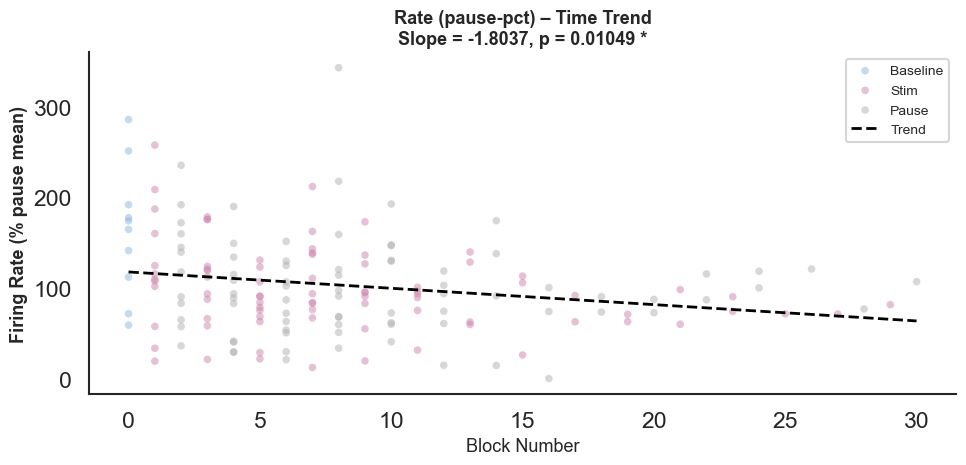

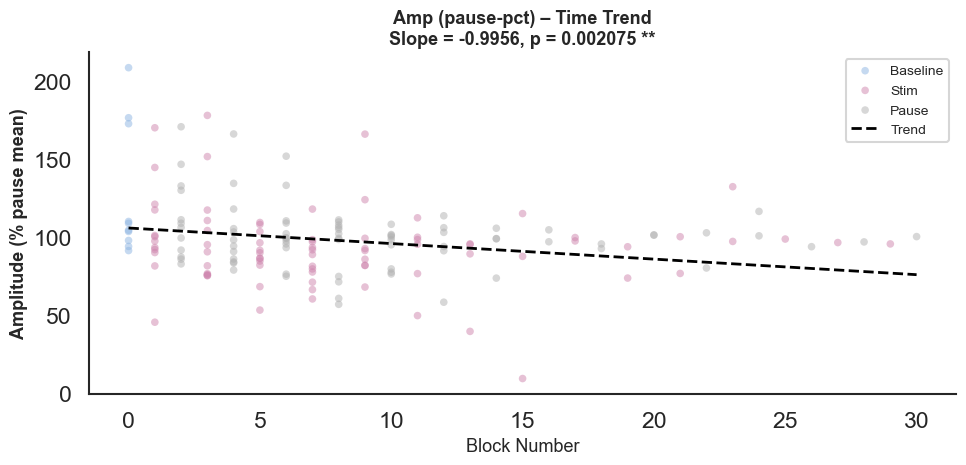

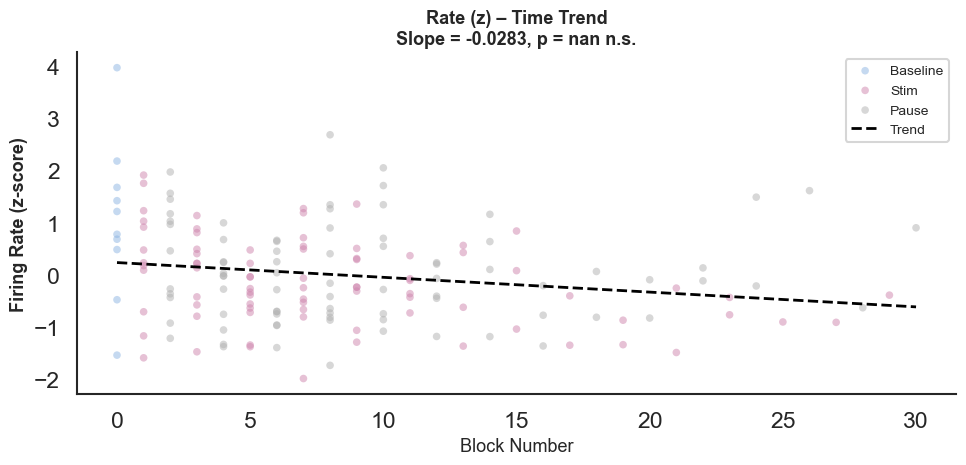

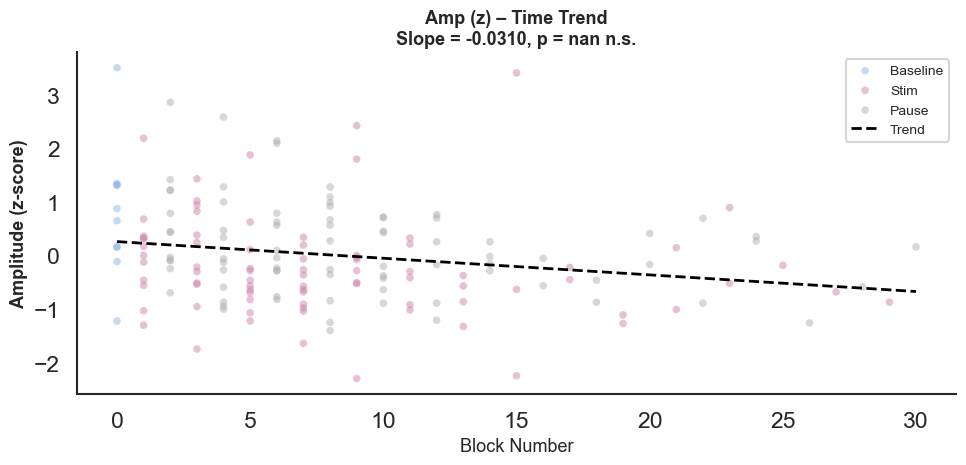

In [16]:
def plot_time_trend(df, dv, label, model_result, title=''):
    data = df.copy()
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0', 'baseline': '#8db4e2'}

    fig, ax = plt.subplots(figsize=(10, 5))
    for bt in ['baseline', 'stim', 'pause']:
        subset = data[data['block_type'] == bt]
        if subset.empty:
            continue
        ax.scatter(subset['block_number'], subset[dv],
                   c=palette.get(bt, 'gray'), alpha=0.5,
                   label=bt.capitalize(), s=30, edgecolors='none')

    x_range = np.linspace(data['block_number'].min(),
                          data['block_number'].max(), 100)
    intercept = model_result.fe_params['Intercept']
    slope = model_result.fe_params.get('block_number', 0)
    ax.plot(x_range, intercept + slope * x_range,
            color='black', linewidth=2, linestyle='--', label='Trend')

    p = model_result.pvalues.get('block_number', np.nan)
    ax.set_title(f'{title}\nSlope = {slope:.4f}, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13)
    ax.set_ylabel(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


# Pause-pct
plot_time_trend(df_rate, rate_pause_col, 'Firing Rate (% pause mean)',
                rate_m2_pause['2A'], 'Rate (pause-pct) – Time Trend')
plot_time_trend(df_amp, amp_pause_col, 'Amplitude (% pause mean)',
                amp_m2_pause['2A'], 'Amp (pause-pct) – Time Trend')

# Z-score
plot_time_trend(df_rate, rate_z_col, 'Firing Rate (z-score)',
                rate_m2_z['2A'], 'Rate (z) – Time Trend')
plot_time_trend(df_amp, amp_z_col, 'Amplitude (z-score)',
                amp_m2_z['2A'], 'Amp (z) – Time Trend')

---
## 6. Model 3 – Immediate Effect (Percent Change from Previous Block)

Percent change is computed on the **normalized** values, so it captures
within-subject block-to-block transitions on a common scale.

In [17]:
def compute_pct_change(df, dv):
    out = df.sort_values(['Subject_ID', 'block_number']).copy()
    out['prev_value'] = out.groupby('Subject_ID')[dv].shift(1)
    out['pct_change'] = ((out[dv] - out['prev_value']) / out['prev_value']) * 100
    out = out.dropna(subset=['pct_change']).copy()
    out = out[np.isfinite(out['pct_change'])].copy()
    return out


def run_immediate_effect_models(df_pct, label):
    results = {}

    # 3A  overall pct change != 0
    res_3a = fit_lmm('pct_change ~ 1', df_pct)
    print_model(res_3a, f'{label} – Model 3A: Pct Change != 0?')
    results['3A'] = res_3a

    # 3B  stim vs pause
    df_3b = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    df_3b['is_stim'] = (df_3b['block_type'] == 'stim').astype(int)
    res_3b = fit_lmm('pct_change ~ is_stim', df_3b)
    print_model(res_3b, f'{label} – Model 3B: Pct Change Stim vs Pause')
    results['3B'] = res_3b

    # 3C  with time interaction
    res_3c = fit_lmm('pct_change ~ is_stim * block_number', df_3b)
    print_model(res_3c, f'{label} – Model 3C: Pct Change ~ Type x Time')
    results['3C'] = res_3c

    return results

### Pause-Mean Normalized

In [18]:
df_rate_pct_pause = compute_pct_change(df_rate, rate_pause_col)
df_amp_pct_pause  = compute_pct_change(df_amp,  amp_pause_col)

rate_m3_pause = run_immediate_effect_models(df_rate_pct_pause,
                                            'Firing Rate (pause-pct)')

Firing Rate (pause-pct) – Model 3A: Pct Change != 0?
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 160     Method:             REML      
No. Groups:       12      Scale:              7597.1815 
Min. group size:  8       Log-Likelihood:     -938.5237 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.3                                  
---------------------------------------------------------
           Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  16.494     8.191  2.014  0.044   0.441  32.547
Group Var   0.000     6.797                              
Firing Rate (pause-pct) – Model 3B: Pct Change Stim vs Pause
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 160     Method:             REML      
No. Groups:       12      Scale:              

In [19]:
amp_m3_pause = run_immediate_effect_models(df_amp_pct_pause,
                                           'Amplitude (pause-pct)')

Amplitude (pause-pct) – Model 3A: Pct Change != 0?
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 159     Method:             REML      
No. Groups:       12      Scale:              1051.4012 
Min. group size:  8       Log-Likelihood:     -776.3992 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.2                                  
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   1.660     2.565  0.647  0.517  -3.367   6.687
Group Var   0.000                                        

Amplitude (pause-pct) – Model 3B: Pct Change Stim vs Pause
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 159     Method:             REML      
No. Groups:       12      Scale:              968

### Z-Score Normalized

In [20]:
df_rate_pct_z = compute_pct_change(df_rate, rate_z_col)
df_amp_pct_z  = compute_pct_change(df_amp,  amp_z_col)

rate_m3_z = run_immediate_effect_models(df_rate_pct_z,
                                        'Firing Rate (z-score)')

Firing Rate (z-score) – Model 3A: Pct Change != 0?
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change 
No. Observations: 160     Method:             REML       
No. Groups:       12      Scale:              197885.6775
Min. group size:  8       Log-Likelihood:     -1197.6867 
Max. group size:  30      Converged:          Yes        
Mean group size:  13.3                                   
---------------------------------------------------------
             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   -30.218   35.971 -0.840 0.401 -100.720 40.285
Group Var     0.000   18.543                             

Firing Rate (z-score) – Model 3B: Pct Change Stim vs Pause
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change 
No. Observations: 160     Method:             REML       
No. Groups:       12      Scale:       

In [21]:
amp_m3_z = run_immediate_effect_models(df_amp_pct_z,
                                       'Amplitude (z-score)')

Amplitude (z-score) – Model 3A: Pct Change != 0?
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change  
No. Observations: 159     Method:             REML        
No. Groups:       12      Scale:              4868476.1734
Min. group size:  8       Log-Likelihood:     -1445.2241  
Max. group size:  30      Converged:          No          
Mean group size:  13.2                                    
----------------------------------------------------------
            Coef.    Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   -331.529  218.830 -1.515 0.130 -760.427 97.370
Group Var 173122.544  156.413                             

Amplitude (z-score) – Model 3B: Pct Change Stim vs Pause
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  pct_change  
No. Observations:  159      Method:              REML        
No. Groups:        12 

### Visualisations – Immediate Effect

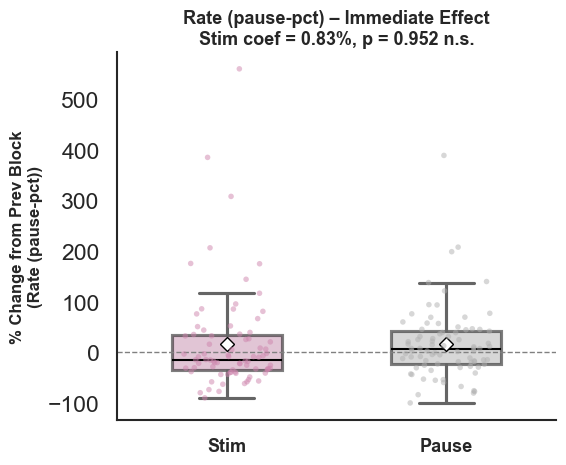

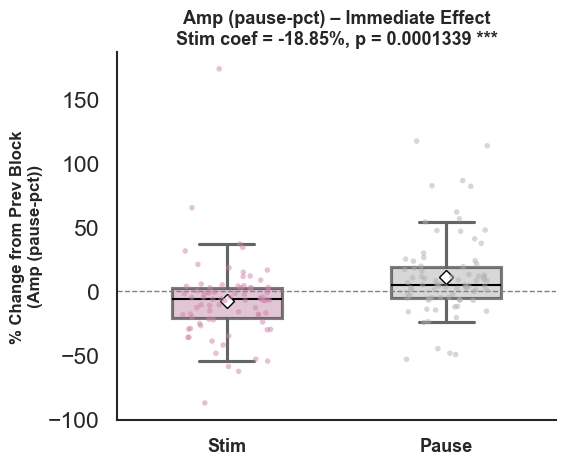

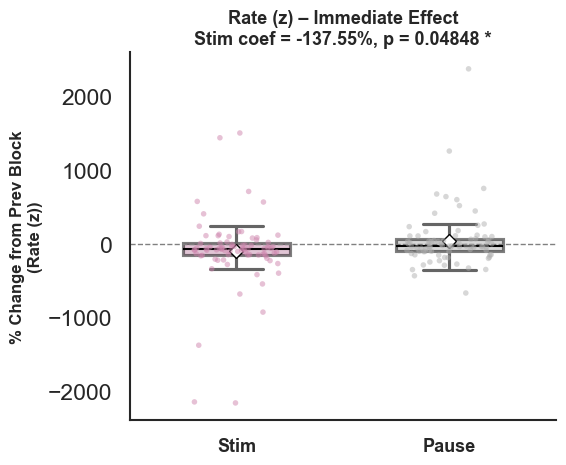

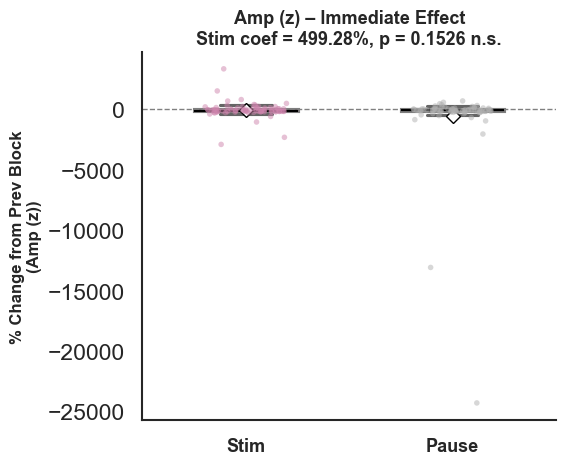

In [22]:
def plot_pct_change(df_pct, label, model_result, title=''):
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()

    fig, ax = plt.subplots(figsize=(6, 5))
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    sns.boxplot(data=data, x='block_type', y='pct_change',
                order=['stim', 'pause'], palette=palette,
                width=0.5, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'white',
                           'markeredgecolor': 'black', 'markersize': 7},
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False, zorder=2, ax=ax)
    sns.stripplot(data=data, x='block_type', y='pct_change',
                  order=['stim', 'pause'], palette=palette,
                  size=4, alpha=0.5, linewidth=0, zorder=3, ax=ax, jitter=0.2)
    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.2f}%, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Stim', 'Pause'], fontsize=13, fontweight='bold')
    ax.set_ylabel(f'% Change from Prev Block\n({label})',
                  fontsize=12, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


# Pause-pct
plot_pct_change(df_rate_pct_pause, 'Rate (pause-pct)',
                rate_m3_pause['3B'], 'Rate (pause-pct) – Immediate Effect')
plot_pct_change(df_amp_pct_pause, 'Amp (pause-pct)',
                amp_m3_pause['3B'], 'Amp (pause-pct) – Immediate Effect')

# Z-score
plot_pct_change(df_rate_pct_z, 'Rate (z)',
                rate_m3_z['3B'], 'Rate (z) – Immediate Effect')
plot_pct_change(df_amp_pct_z, 'Amp (z)',
                amp_m3_z['3B'], 'Amp (z) – Immediate Effect')

---
## 7. Per-Patient Correlation: Rate vs Amplitude Reduction (Normalized)

N = 12
Pearson  r = -0.140, p = 0.6633
Spearman rho = -0.189, p = 0.5567


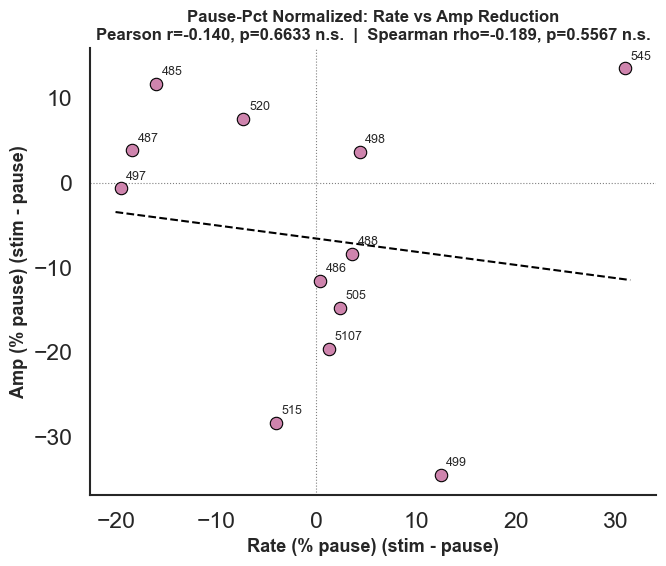

N = 12
Pearson  r = -0.257, p = 0.4193
Spearman rho = -0.266, p = 0.4038


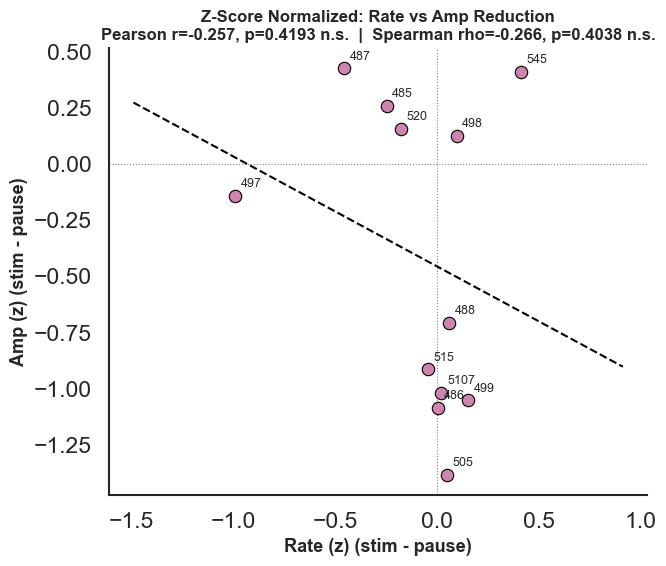

In [23]:
def per_subject_stim_effect(df, dv):
    sp = df[df['block_type'].isin(['stim', 'pause'])].copy()
    means = sp.groupby(['Subject_ID', 'block_type'])[dv].mean().unstack('block_type')
    means['diff'] = means['stim'] - means['pause']
    return means[['stim', 'pause', 'diff']]


def plot_correlation(df_rate, df_amp, rate_dv, amp_dv, rate_label, amp_label, title):
    rate_eff = per_subject_stim_effect(df_rate, rate_dv)
    amp_eff  = per_subject_stim_effect(df_amp,  amp_dv)

    corr_df = pd.DataFrame({
        'rate_diff': rate_eff['diff'],
        'amp_diff':  amp_eff['diff'],
    }).dropna()

    r_p, p_p = pearsonr(corr_df['rate_diff'], corr_df['amp_diff'])
    r_s, p_s = spearmanr(corr_df['rate_diff'], corr_df['amp_diff'])

    print(f'N = {len(corr_df)}')
    print(f'Pearson  r = {r_p:.3f}, p = {p_p:.4g}')
    print(f'Spearman rho = {r_s:.3f}, p = {p_s:.4g}')

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(corr_df['rate_diff'], corr_df['amp_diff'],
               s=80, c='#ce84ad', edgecolors='black', linewidth=0.8, zorder=3)
    for subj, row in corr_df.iterrows():
        ax.annotate(subj, (row['rate_diff'], row['amp_diff']),
                    fontsize=9, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

    m, b = np.polyfit(corr_df['rate_diff'], corr_df['amp_diff'], 1)
    x_line = np.linspace(corr_df['rate_diff'].min() - 0.5,
                         corr_df['rate_diff'].max() + 0.5, 100)
    ax.plot(x_line, m * x_line + b, color='black',
            linewidth=1.5, linestyle='--', zorder=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':', zorder=1)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', zorder=1)

    ax.set_xlabel(f'{rate_label} (stim - pause)', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{amp_label} (stim - pause)', fontsize=13, fontweight='bold')
    ax.set_title(
        f'{title}\n'
        f'Pearson r={r_p:.3f}, p={p_p:.4g} {p_to_stars(p_p)}  |  '
        f'Spearman rho={r_s:.3f}, p={p_s:.4g} {p_to_stars(p_s)}',
        fontsize=12, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


# Pause-pct
plot_correlation(df_rate, df_amp, rate_pause_col, amp_pause_col,
                 'Rate (% pause)', 'Amp (% pause)',
                 'Pause-Pct Normalized: Rate vs Amp Reduction')

# Z-score
plot_correlation(df_rate, df_amp, rate_z_col, amp_z_col,
                 'Rate (z)', 'Amp (z)',
                 'Z-Score Normalized: Rate vs Amp Reduction')

---
## 8. Summary Table

In [24]:
def extract_row(model_id, measure, norm, result, key_coef):
    coef = result.fe_params.get(key_coef, np.nan)
    p = result.pvalues.get(key_coef, np.nan)
    ci = result.conf_int().loc[key_coef] if key_coef in result.conf_int().index else [np.nan, np.nan]
    return {
        'Model': model_id,
        'Measure': measure,
        'Normalization': norm,
        'Coefficient': key_coef,
        'Estimate': round(coef, 4),
        'p-value': round(p, 4),
        'Sig.': p_to_stars(p),
        'CI_low': round(ci[0], 4) if not np.isnan(ci[0]) else np.nan,
        'CI_high': round(ci[1], 4) if not np.isnan(ci[1]) else np.nan,
        'N_obs': int(result.nobs),
    }

rows = []

for norm_label, r_m1, a_m1, r_m2, a_m2, r_m3, a_m3 in [
    ('pause-pct', rate_m1_pause, amp_m1_pause, rate_m2_pause, amp_m2_pause,
     rate_m3_pause, amp_m3_pause),
    ('z-score',   rate_m1_z, amp_m1_z, rate_m2_z, amp_m2_z,
     rate_m3_z, amp_m3_z),
]:
    # Model 1
    rows.append(extract_row('1A: Stim vs Non-Stim', 'Rate', norm_label, r_m1['1A'], 'is_stim'))
    rows.append(extract_row('1A: Stim vs Non-Stim', 'Amp',  norm_label, a_m1['1A'], 'is_stim'))
    rows.append(extract_row('1B: Stim vs Pause',    'Rate', norm_label, r_m1['1B'], 'is_stim'))
    rows.append(extract_row('1B: Stim vs Pause',    'Amp',  norm_label, a_m1['1B'], 'is_stim'))
    # Model 2
    rows.append(extract_row('2A: Time Trend',  'Rate', norm_label, r_m2['2A'], 'block_number'))
    rows.append(extract_row('2A: Time Trend',  'Amp',  norm_label, a_m2['2A'], 'block_number'))
    rows.append(extract_row('2B: Time x Type', 'Rate', norm_label, r_m2['2B'], 'block_number:is_stim'))
    rows.append(extract_row('2B: Time x Type', 'Amp',  norm_label, a_m2['2B'], 'block_number:is_stim'))
    # Model 3
    rows.append(extract_row('3A: Pct != 0',        'Rate', norm_label, r_m3['3A'], 'Intercept'))
    rows.append(extract_row('3A: Pct != 0',        'Amp',  norm_label, a_m3['3A'], 'Intercept'))
    rows.append(extract_row('3B: Pct Stim vs Pause','Rate', norm_label, r_m3['3B'], 'is_stim'))
    rows.append(extract_row('3B: Pct Stim vs Pause','Amp',  norm_label, a_m3['3B'], 'is_stim'))

df_summary = pd.DataFrame(rows)
display(df_summary)

,Model,Measure,Normalization,Coefficient,Estimate,p-value,Sig.,CI_low,CI_high,N_obs
0,1A: Stim vs Non-Stim,Rate,pause-pct,is_stim,-8.9974,0.2811,n.s.,-25.3581,7.3632,172
1,1A: Stim vs Non-Stim,Amp,pause-pct,is_stim,-9.2747,0.0148,*,-16.7324,-1.8171,171
2,1B: Stim vs Pause,Rate,pause-pct,is_stim,-2.0757,0.7979,n.s.,-17.9647,13.8133,162
3,1B: Stim vs Pause,Amp,pause-pct,is_stim,-6.3616,0.0811,n.s.,-13.5105,0.7873,161
4,2A: Time Trend,Rate,pause-pct,block_number,-1.8037,0.0105,*,-3.1850,-0.4224,172
5,2A: Time Trend,Amp,pause-pct,block_number,-0.9956,0.0021,**,-1.6292,-0.3619,171
6,2B: Time x Type,Rate,pause-pct,block_number:is_stim,-1.0478,0.3849,n.s.,-3.4110,1.3155,162
7,2B: Time x Type,Amp,pause-pct,block_number:is_stim,0.1300,0.8080,n.s.,-0.9185,1.1785,161
8,3A: Pct != 0,Rate,pause-pct,Intercept,16.4940,0.0440,*,0.4407,32.5472,160
9,3A: Pct != 0,Amp,pause-pct,Intercept,1.6600,0.5175,n.s.,-3.3668,6.6867,159


In [ ]:
# Save
df_summary.to_csv('hierarchical_models_normalized_summary.csv', index=False)
print('Summary saved to hierarchical_models_normalized_summary.csv')

---
## 9. Comparison: Raw vs Normalized

Side-by-side comparison of significance patterns across normalizations.

In [25]:
# Pivot to show significance patterns
comparison = df_summary.pivot_table(
    index=['Model', 'Measure'],
    columns='Normalization',
    values=['Estimate', 'p-value', 'Sig.'],
    aggfunc='first'
)
display(comparison['Sig.'])

Normalization                 pause-pct z-score
Model                 Measure                  
1A: Stim vs Non-Stim  Amp             *      **
                      Rate         n.s.       *
1B: Stim vs Pause     Amp          n.s.       *
                      Rate         n.s.    n.s.
2A: Time Trend        Amp            **    n.s.
                      Rate            *    n.s.
2B: Time x Type       Amp          n.s.    n.s.
                      Rate         n.s.       *
3A: Pct != 0          Amp          n.s.    n.s.
                      Rate            *    n.s.
3B: Pct Stim vs Pause Amp           ***    n.s.
                      Rate         n.s.       *